Paquetes necesarios

Hacemos uso del mismo *environment* de la primera práctica

In [53]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

img = cv2.imread('mandril.jpg')

if img is None:
    print("Error: No se ha encontrado la imagen 'mandril.jpg'.")
    exit()

gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo de píxeles blancos en una fila: 220.0
Número de filas que superan el 90% del máximo: 7
Posiciones de las filas: [  6  12  15  20  21  88 100]


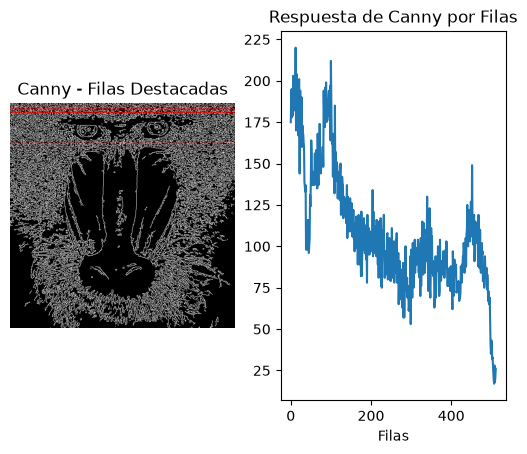

In [54]:
canny = cv2.Canny(gris, 100, 200)

# Cuenta el número de píxeles blancos por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = row_counts[:, 0] / 255

# Valor máximo de píxeles blancos por filas
maxfil = np.max(rows)

# Filas que cumplen la condición >= 0.90 * maxfil
condicion = 0.90 * maxfil
filas_destacadas = np.where(rows >= condicion)[0]

print(f"Valor máximo de píxeles blancos en una fila: {maxfil}")
print(f"Número de filas que superan el 90% del máximo: {len(filas_destacadas)}")
print(f"Posiciones de las filas: {filas_destacadas}")

# Marcamos con líneas rojas en la imagen de Canny
# Convertimos Canny a BGR para dibujar en color
canny_resaltado = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for f in filas_destacadas:
    cv2.line(canny_resaltado, (0, f), (canny.shape[1], f), (255, 0, 0), 1)

plt.subplot(1, 2, 1)
plt.title("Canny - Filas Destacadas")
plt.axis("off")
plt.imshow(canny_resaltado)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny por Filas")
plt.xlabel("Filas")
plt.ylabel("% Píxeles")
plt.plot(range(len(rows)), rows)
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

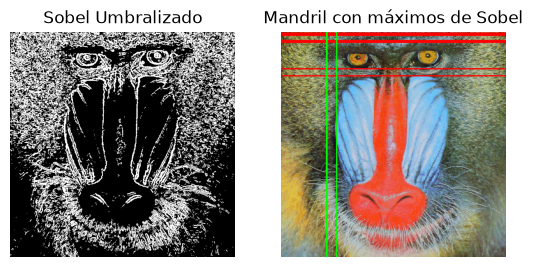

In [ ]:
import cv2
import numpy as np

print("\n--- EJECUTANDO TAREA 3: CORTINA ANTI-AMARILLO ---")
print("Muestra algo amarillo a la cámara. Pulsa 'ESC' para salir.")

vid = cv2.VideoCapture(0)

# Definir los rangos de color AMARILLO en el espacio HSV
# El amarillo en OpenCV suele estar alrededor del Tono (Hue) 20-35
amarillo_bajo = np.array([20, 100, 100])
amarillo_alto = np.array([35, 255, 255])

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # Efecto espejo
    framem = cv2.flip(frame, 1)
    
    # Convertir de BGR (por defecto en OpenCV) a HSV
    hsv = cv2.cvtColor(framem, cv2.COLOR_BGR2HSV)
    
    # Crear una máscara que solo deje pasar los píxeles amarillos
    mask = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)
    
    # Operaciones morfológicas para limpiar el ruido (puntitos amarillos sueltos)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel, iterations=2)
    
    # Encontrar los contornos de los objetos amarillos detectados
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Quedarnos con el contorno amarillo más grande para no volvernos locos con el ruido
        c = max(contours, key=cv2.contourArea)
        
        # Umbral mínimo de tamaño para asegurar que es un objeto y no un reflejo o un píxel suelto
        if cv2.contourArea(c) > 500:
            x, y, w, h = cv2.boundingRect(c)
            
            # Dibujar la "cortina virtual" (un bloque negro vertical que tapa toda esa columna)
            cv2.rectangle(framem, (x - 20, 0), (x + w + 20, framem.shape[0]), (0, 0, 0), -1)
            
            # Añadir texto a la cortina
            cv2.putText(framem, "CENSURADO", (x, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.imshow('Cortina Anti-Amarillo', framem)
    # cv2.imshow('Mascara Debug', mask) # Descomenta esto para ver en blanco y negro lo que detecta
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

Comparativa Canny vs Sobel:
En la práctica, Sobel resulta un poco menos preciso, nos da bordes bastante gruesos y algo borrosos porque depende totalmente del umbral que le pongamos. Además, si la imagen tiene mucha textura, Sobel se confunde y detecta demasiados píxeles.

Canny, en cambio, hace un trabajo mucho más limpio. Como aplica pasos extra para limpiar la imagen (como la supresión de no-máximos y la histéresis), logra dibujar líneas nítidas de un solo píxel de grosor. Básicamente, Canny consigue capturar el contorno real y la estructura de la imagen de forma mucho más precisa que Sobel.

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
import cv2
import numpy as np
import threading

# Frecuencias de las notas musicales (Do, Re, Mi, Fa, Sol, La, Si)
notas_freq = [261, 293, 329, 349, 392, 440, 493]
notas_nombres = ["Do", "Re", "Mi", "Fa", "Sol", "La", "Si"]

# Variables para controlar que la nota no suene repetidamente mientras mantienes el pie
teclas_pulsadas = [False] * 7

def tocar_nota(frecuencia):
    """
    Reproduce un pitido con la frecuencia dada.
    Usa winsound (solo Windows). El try-except evita errores si se ejecuta en otro SO.
    """
    try:
        import winsound
        # Frecuencia en Hz, duración en milisegundos
        winsound.Beep(int(frecuencia), 300)
    except ImportError:
        pass

print("\n--- EJECUTANDO TAREA 3: PIANO VIRTUAL INTERACTIVO ---")
print("Sitúate lejos de la cámara para que se te vean los pies, ¡y empieza a pisar!")
print("Pulsa 'ESC' para salir.")

vid = cv2.VideoCapture(0)
# Sustractor de fondo para detectar el movimiento
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=40, detectShadows=False)

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # Efecto espejo para que sea intuitivo interactuar
    frame = cv2.flip(frame, 1)
    alto, ancho = frame.shape[:2]

    # Aplicar sustracción de fondo
    fgmask = eliminadorFondo.apply(frame)
    
    # Limpiar un poco el ruido de la máscara con una apertura morfológica
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, kernel)

    # ==========================================
    # LÓGICA DEL PIANO VIRTUAL
    # ==========================================
    # El piano ocupará el 30% inferior de la pantalla
    alto_tecla = int(alto * 0.3)
    y_inicio = alto - alto_tecla
    ancho_tecla = ancho // 7 # 7 teclas para las 7 notas musicales

    # Dibujamos un rectángulo semitransparente como base del piano (opcional pero queda bien)
    overlay = frame.copy()

    for i in range(7):
        x_inicio = i * ancho_tecla
        x_fin = (i + 1) * ancho_tecla
        
        # Extraemos la Región de Interés (ROI) de la MÁSCARA correspondiente a esta tecla
        roi_mask = fgmask[y_inicio:alto, x_inicio:x_fin]
        
        # Contamos cuántos píxeles de movimiento (blancos) hay en esa tecla
        movimiento = cv2.countNonZero(roi_mask)
        
        # Umbral: consideramos la tecla "pisada" si hay movimiento en el 10% de su área
        umbral_activacion = (alto_tecla * ancho_tecla) * 0.10 

        if movimiento > umbral_activacion:
            # Si hay movimiento y la tecla NO estaba pulsada ya, reproducimos el sonido
            if not teclas_pulsadas[i]:
                threading.Thread(target=tocar_nota, args=(notas_freq[i],), daemon=True).start()
                teclas_pulsadas[i] = True
            
            # Dibujar la tecla ILUMINADA (ej. color cyan)
            cv2.rectangle(frame, (x_inicio, y_inicio), (x_fin, alto), (255, 255, 0), -1)
            cv2.putText(frame, notas_nombres[i], (x_inicio + int(ancho_tecla*0.2), y_inicio + int(alto_tecla*0.6)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3)
        else:
            # Si no hay suficiente movimiento, reseteamos el estado de la tecla
            teclas_pulsadas[i] = False
            
            # Dibujar la tecla NORMAL (blanca con borde negro)
            cv2.rectangle(overlay, (x_inicio, y_inicio), (x_fin, alto), (255, 255, 255), -1)
            cv2.rectangle(overlay, (x_inicio, y_inicio), (x_fin, alto), (0, 0, 0), 2)
            cv2.putText(overlay, notas_nombres[i], (x_inicio + int(ancho_tecla*0.2), y_inicio + int(alto_tecla*0.6)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3)

    # Mezclamos el overlay (teclas blancas) con el frame original para dar un efecto de transparencia (alfa=0.7)
    # Las teclas iluminadas se dibujaron directamente en 'frame', así que resaltarán más.
    cv2.addWeighted(overlay, 0.7, frame, 0.3, 0, frame)

    # Instrucciones en pantalla
    cv2.putText(frame, "Pisa las teclas para tocar!", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Mostramos el resultado
    cv2.imshow('Piano Virtual Interactivo', frame)
    # cv2.imshow('Mascara (Debug)', fgmask) # Descomenta esto si quieres ver cómo detecta el movimiento
    
    if cv2.waitKey(20) == 27: # 27 es ESC
        break

vid.release()
cv2.destroyAllWindows()